# Week 1: Data Acquisition, Cleaning, and Preprocessing

## Air Quality Dataset Analysis Using Python

**Internship:** Data Science Using Python  
**Task:** Week 1 – Data Acquisition, Cleaning, and Preprocessing  
**Tools:** Python, Pandas, NumPy, Matplotlib, Seaborn, Jupyter Notebook  
**Dataset Source:** UCI Machine Learning Repository

## 1. Objective

The objective of this task is to acquire a publicly available dataset and perform systematic data cleaning and preprocessing using Python.

The analysis focuses on understanding the structure and quality of the dataset, identifying missing values, detecting inconsistent or erroneous entries, investigating outliers, and preparing the data for further analysis.

The preprocessing decisions are documented along with their rationale, potential challenges, and possible impacts on subsequent data analysis.

## 2. Dataset Selection

For this project, the Air Quality dataset from the UCI Machine Learning Repository has been selected.

The dataset contains air-quality measurements collected using gas multisensor devices deployed in an Italian city. It contains multiple pollutant-related measurements along with environmental sensor readings.

The dataset is suitable for this task because it contains data-quality challenges such as missing/invalid values, which provide an opportunity to demonstrate practical data cleaning and preprocessing techniques.

In [2]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully.")
print("Pandas:", pd.__version__)
print("NumPy:", np.__version__)
print("Matplotlib:", matplotlib.__version__)
print("Seaborn:", sns.__version__)

Libraries imported successfully.
Pandas: 3.0.6
NumPy: 2.5.3
Matplotlib: 3.11.2
Seaborn: 0.13.2


## 3. Data Acquisition

The Air Quality dataset was obtained from the UCI Machine Learning Repository, a publicly available and widely used source of datasets for machine learning and data analysis.

The selected dataset contains hourly averaged responses from an air-quality chemical multisensor device deployed in an Italian city. It contains 9,358 instances and 15 features.

The dataset was selected because it contains real-world data quality issues, including missing values represented by the value `-200`. This makes it suitable for demonstrating data cleaning and preprocessing techniques.

**Source:** UCI Machine Learning Repository  
**Dataset:** Air Quality  
**DOI:** https://doi.org/10.24432/C59K5F

In [3]:
from ucimlrepo import fetch_ucirepo

# Fetch the Air Quality dataset from UCI
air_quality = fetch_ucirepo(id=360)

# Get the feature data
df = air_quality.data.features

print("Dataset downloaded successfully.")
print("Shape:", df.shape)

Dataset downloaded successfully.
Shape: (9357, 15)


In [4]:
df.head()

,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,3/10/2004,18:00:00,2.6,1360,150,11.9,1046,166,1056,113,1692,1268,13.6,48.9,0.7578
1,3/10/2004,19:00:00,2.0,1292,112,9.4,955,103,1174,92,1559,972,13.3,47.7,0.7255
2,3/10/2004,20:00:00,2.2,1402,88,9.0,939,131,1140,114,1555,1074,11.9,54.0,0.7502
3,3/10/2004,21:00:00,2.2,1376,80,9.2,948,172,1092,122,1584,1203,11.0,60.0,0.7867
4,3/10/2004,22:00:00,1.6,1272,51,6.5,836,131,1205,116,1490,1110,11.2,59.6,0.7888


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9357 entries, 0 to 9356
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Date           9357 non-null   str    
 1   Time           9357 non-null   str    
 2   CO(GT)         9357 non-null   float64
 3   PT08.S1(CO)    9357 non-null   int64  
 4   NMHC(GT)       9357 non-null   int64  
 5   C6H6(GT)       9357 non-null   float64
 6   PT08.S2(NMHC)  9357 non-null   int64  
 7   NOx(GT)        9357 non-null   int64  
 8   PT08.S3(NOx)   9357 non-null   int64  
 9   NO2(GT)        9357 non-null   int64  
 10  PT08.S4(NO2)   9357 non-null   int64  
 11  PT08.S5(O3)    9357 non-null   int64  
 12  T              9357 non-null   float64
 13  RH             9357 non-null   float64
 14  AH             9357 non-null   float64
dtypes: float64(5), int64(8), str(2)
memory usage: 1.1 MB


In [6]:
import os

os.makedirs("../data/raw", exist_ok=True)

df.to_csv("../data/raw/AirQuality_raw.csv", index=False)

print("Raw dataset saved successfully.")

Raw dataset saved successfully.


## 4. Initial Data Exploration

Before performing any cleaning operations, the dataset was explored to understand its dimensions, structure, data types, and overall quality.

The initial exploration helps identify potential issues such as missing values, duplicate records, incorrect data types, and unusual values that may require further preprocessing.

In [7]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 9357
Number of columns: 15


In [8]:
print("First 5 records:")
display(df.head())

print("\nLast 5 records:")
display(df.tail())

First 5 records:


,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,3/10/2004,18:00:00,2.6,1360,150,11.9,1046,166,1056,113,1692,1268,13.6,48.9,0.7578
1,3/10/2004,19:00:00,2.0,1292,112,9.4,955,103,1174,92,1559,972,13.3,47.7,0.7255
2,3/10/2004,20:00:00,2.2,1402,88,9.0,939,131,1140,114,1555,1074,11.9,54.0,0.7502
3,3/10/2004,21:00:00,2.2,1376,80,9.2,948,172,1092,122,1584,1203,11.0,60.0,0.7867
4,3/10/2004,22:00:00,1.6,1272,51,6.5,836,131,1205,116,1490,1110,11.2,59.6,0.7888



Last 5 records:


,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
9352,4/4/2005,10:00:00,3.1,1314,-200,13.5,1101,472,539,190,1374,1729,21.9,29.3,0.7568
9353,4/4/2005,11:00:00,2.4,1163,-200,11.4,1027,353,604,179,1264,1269,24.3,23.7,0.7119
9354,4/4/2005,12:00:00,2.4,1142,-200,12.4,1063,293,603,175,1241,1092,26.9,18.3,0.6406
9355,4/4/2005,13:00:00,2.1,1003,-200,9.5,961,235,702,156,1041,770,28.3,13.5,0.5139
9356,4/4/2005,14:00:00,2.2,1071,-200,11.9,1047,265,654,168,1129,816,28.5,13.1,0.5028


In [9]:
print("Column names:")
for column in df.columns:
    print("-", column)

Column names:
- Date
- Time
- CO(GT)
- PT08.S1(CO)
- NMHC(GT)
- C6H6(GT)
- PT08.S2(NMHC)
- NOx(GT)
- PT08.S3(NOx)
- NO2(GT)
- PT08.S4(NO2)
- PT08.S5(O3)
- T
- RH
- AH


In [10]:
print("Data types:")
display(df.dtypes)

Data types:


Date                 str
Time                 str
CO(GT)           float64
PT08.S1(CO)        int64
NMHC(GT)           int64
C6H6(GT)         float64
PT08.S2(NMHC)      int64
NOx(GT)            int64
PT08.S3(NOx)       int64
NO2(GT)            int64
PT08.S4(NO2)       int64
PT08.S5(O3)        int64
T                float64
RH               float64
AH               float64
dtype: object

In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9357 entries, 0 to 9356
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Date           9357 non-null   str    
 1   Time           9357 non-null   str    
 2   CO(GT)         9357 non-null   float64
 3   PT08.S1(CO)    9357 non-null   int64  
 4   NMHC(GT)       9357 non-null   int64  
 5   C6H6(GT)       9357 non-null   float64
 6   PT08.S2(NMHC)  9357 non-null   int64  
 7   NOx(GT)        9357 non-null   int64  
 8   PT08.S3(NOx)   9357 non-null   int64  
 9   NO2(GT)        9357 non-null   int64  
 10  PT08.S4(NO2)   9357 non-null   int64  
 11  PT08.S5(O3)    9357 non-null   int64  
 12  T              9357 non-null   float64
 13  RH             9357 non-null   float64
 14  AH             9357 non-null   float64
dtypes: float64(5), int64(8), str(2)
memory usage: 1.1 MB


## 5. Missing Value Analysis

Missing values can affect statistical analysis, visualization, and machine learning models. Therefore, missing and invalid values must be identified before further processing.

The Air Quality dataset uses the value `-200` to represent missing or invalid sensor readings. These values need to be identified and handled appropriately rather than being treated as genuine measurements.

In [12]:
missing_values = df.isnull().sum()

print("Missing values detected using Pandas:")
display(missing_values)

Missing values detected using Pandas:


Date             0
Time             0
CO(GT)           0
PT08.S1(CO)      0
NMHC(GT)         0
C6H6(GT)         0
PT08.S2(NMHC)    0
NOx(GT)          0
PT08.S3(NOx)     0
NO2(GT)          0
PT08.S4(NO2)     0
PT08.S5(O3)      0
T                0
RH               0
AH               0
dtype: int64

In [13]:
print("Total missing values:", df.isnull().sum().sum())

Total missing values: 0


In [14]:
invalid_200 = (df == -200).sum()

print("Number of -200 values in each column:")
display(invalid_200)

Number of -200 values in each column:


Date                0
Time                0
CO(GT)           1683
PT08.S1(CO)       366
NMHC(GT)         8443
C6H6(GT)          366
PT08.S2(NMHC)     366
NOx(GT)          1639
PT08.S3(NOx)      366
NO2(GT)          1642
PT08.S4(NO2)      366
PT08.S5(O3)       366
T                 366
RH                366
AH                366
dtype: int64

In [15]:
print("Total -200 values:", (df == -200).sum().sum())

Total -200 values: 16701


In [16]:
missing_percentage = ((df == -200).sum() / len(df)) * 100

missing_summary = pd.DataFrame({
    "Invalid (-200) Count": (df == -200).sum(),
    "Invalid (-200) Percentage": missing_percentage
})

display(missing_summary)

,Invalid (-200) Count,Invalid (-200) Percentage
Date,0,0.000000
Time,0,0.000000
CO(GT),1683,17.986534
PT08.S1(CO),366,3.911510
NMHC(GT),8443,90.231912
C6H6(GT),366,3.911510
PT08.S2(NMHC),366,3.911510
NOx(GT),1639,17.516298
PT08.S3(NOx),366,3.911510
NO2(GT),1642,17.548360


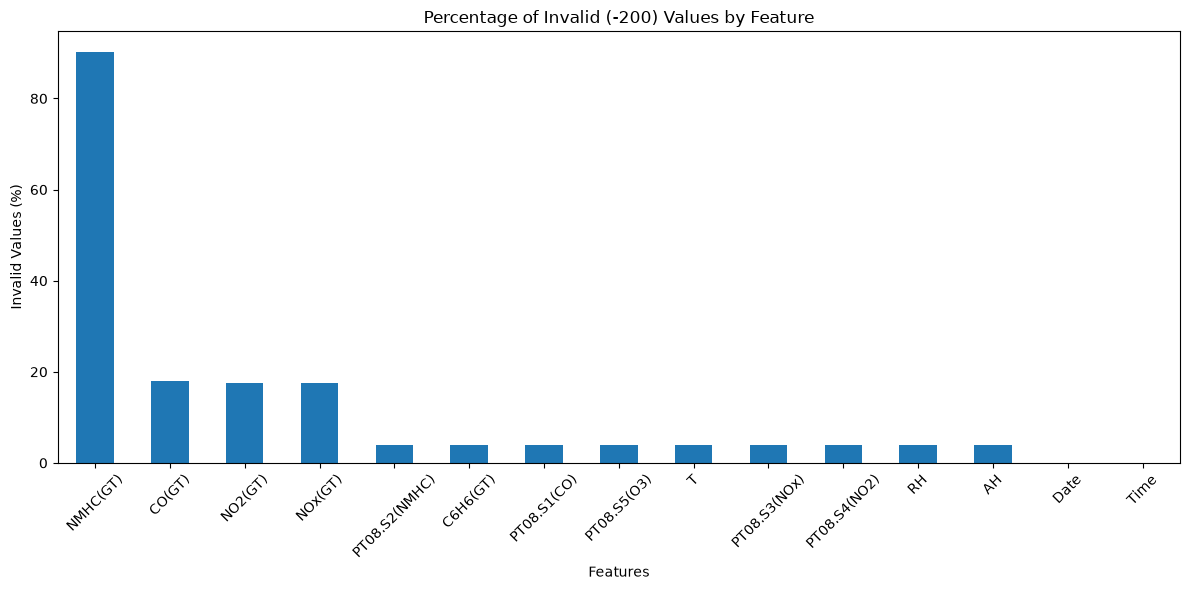

In [17]:
missing_summary["Invalid (-200) Percentage"].sort_values(
    ascending=False
).plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Percentage of Invalid (-200) Values by Feature")
plt.xlabel("Features")
plt.ylabel("Invalid Values (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 6. Duplicate Record Analysis

Duplicate records can introduce bias into statistical analysis and machine learning models. Therefore, duplicate rows were checked before performing further preprocessing.

In [18]:
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


In [19]:
print("Percentage of duplicate rows:",
      (duplicate_count / len(df)) * 100)

Percentage of duplicate rows: 0.0


In [20]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
CO(GT),9357.0,-34.207524,77.657170,-200.0,0.6000,1.5000,2.6000,11.900
PT08.S1(CO),9357.0,1048.990061,329.832710,-200.0,921.0000,1053.0000,1221.0000,2040.000
NMHC(GT),9357.0,-159.090093,139.789093,-200.0,-200.0000,-200.0000,-200.0000,1189.000
C6H6(GT),9357.0,1.865683,41.380206,-200.0,4.0000,7.9000,13.6000,63.700
PT08.S2(NMHC),9357.0,894.595276,342.333252,-200.0,711.0000,895.0000,1105.0000,2214.000
NOx(GT),9357.0,168.616971,257.433866,-200.0,50.0000,141.0000,284.0000,1479.000
PT08.S3(NOx),9357.0,794.990168,321.993552,-200.0,637.0000,794.0000,960.0000,2683.000
NO2(GT),9357.0,58.148873,126.940455,-200.0,53.0000,96.0000,133.0000,340.000
PT08.S4(NO2),9357.0,1391.479641,467.210125,-200.0,1185.0000,1446.0000,1662.0000,2775.000
PT08.S5(O3),9357.0,975.072032,456.938184,-200.0,700.0000,942.0000,1255.0000,2523.000


## 7. Data Cleaning

The exploratory analysis identified a major data-quality issue: the dataset uses the value `-200` to represent missing or invalid sensor measurements.

Because `-200` is not a meaningful measurement for the sensor variables, these values must not be treated as genuine observations. The raw dataset is preserved separately, and a copy is created for cleaning and preprocessing.

In [21]:
# Create a copy of the raw dataset for cleaning
df_clean = df.copy()

print("Original dataset shape:", df.shape)
print("Cleaning dataset shape:", df_clean.shape)

Original dataset shape: (9357, 15)
Cleaning dataset shape: (9357, 15)


### 7.1 Converting Invalid Values to NaN

The value `-200` is used by the dataset to indicate missing or invalid sensor readings. Therefore, these values are converted to `NaN`.

Using `NaN` allows Pandas to correctly recognize these observations as missing and makes it possible to apply appropriate missing-value handling techniques.

In [22]:
# Replace -200 with NaN
df_clean = df_clean.replace(-200, np.nan)

print("Total missing values after conversion:",
      df_clean.isna().sum().sum())

Total missing values after conversion: 16701


In [23]:
missing_summary = pd.DataFrame({
    "Missing Count": df_clean.isna().sum(),
    "Missing Percentage": (df_clean.isna().sum() / len(df_clean)) * 100
})

display(missing_summary)

,Missing Count,Missing Percentage
Date,0,0.000000
Time,0,0.000000
CO(GT),1683,17.986534
PT08.S1(CO),366,3.911510
NMHC(GT),8443,90.231912
C6H6(GT),366,3.911510
PT08.S2(NMHC),366,3.911510
NOx(GT),1639,17.516298
PT08.S3(NOx),366,3.911510
NO2(GT),1642,17.548360


In [24]:
missing_summary.sort_values(
    by="Missing Percentage",
    ascending=False
)

,Missing Count,Missing Percentage
NMHC(GT),8443,90.231912
CO(GT),1683,17.986534
NO2(GT),1642,17.548360
NOx(GT),1639,17.516298
PT08.S2(NMHC),366,3.911510
C6H6(GT),366,3.911510
PT08.S1(CO),366,3.911510
PT08.S5(O3),366,3.911510
T,366,3.911510
PT08.S3(NOx),366,3.911510


In [25]:
missing_summary.sort_values(
    by="Missing Percentage",
    ascending=False
)

,Missing Count,Missing Percentage
NMHC(GT),8443,90.231912
CO(GT),1683,17.986534
NO2(GT),1642,17.548360
NOx(GT),1639,17.516298
PT08.S2(NMHC),366,3.911510
C6H6(GT),366,3.911510
PT08.S1(CO),366,3.911510
PT08.S5(O3),366,3.911510
T,366,3.911510
PT08.S3(NOx),366,3.911510


In [26]:
duplicate_count = df_clean.duplicated().sum()

print("Duplicate rows:", duplicate_count)
print(
    "Duplicate percentage:",
    round((duplicate_count / len(df_clean)) * 100, 2),
    "%"
)

Duplicate rows: 0
Duplicate percentage: 0.0 %


### 7.2 Date and Time Preprocessing

The `Date` and `Time` columns were initially stored as strings. Since the dataset represents hourly measurements, these fields should be converted into a proper datetime representation.

Combining the two fields into a single datetime column will make chronological sorting, time-based analysis, and interpolation more reliable.

In [27]:
# Combine Date and Time into a single datetime column
df_clean["Datetime"] = pd.to_datetime(
    df_clean["Date"] + " " + df_clean["Time"],
    dayfirst=False,
    errors="coerce"
)

print("Datetime conversion completed.")
print("Invalid datetime values:", df_clean["Datetime"].isna().sum())

Datetime conversion completed.
Invalid datetime values: 0


In [28]:
df_clean[["Date", "Time", "Datetime"]].head()

,Date,Time,Datetime
0,3/10/2004,18:00:00,2004-03-10 18:00:00
1,3/10/2004,19:00:00,2004-03-10 19:00:00
2,3/10/2004,20:00:00,2004-03-10 20:00:00
3,3/10/2004,21:00:00,2004-03-10 21:00:00
4,3/10/2004,22:00:00,2004-03-10 22:00:00


## 8. Missing-Value Treatment

After converting the dataset's `-200` markers to `NaN`, the percentage of missing observations was calculated for each feature.

Features with an extremely high proportion of missing values provide limited reliable information. Filling such a large proportion of missing observations could introduce substantial artificial information and potentially distort subsequent analysis.

Therefore, features with more than 50% missing values will be considered for removal. Features with a lower proportion of missing values will be retained and their missing observations will be handled using time-series interpolation.

In [29]:
# Identify columns with more than 50% missing values

high_missing = missing_summary[
    missing_summary["Missing Percentage"] > 50
]

print("Columns with more than 50% missing values:")
display(high_missing)

Columns with more than 50% missing values:


,Missing Count,Missing Percentage
NMHC(GT),8443,90.231912


In [30]:
# Store the names of highly incomplete columns
columns_to_drop = high_missing.index.tolist()

print("Columns selected for removal:")
print(columns_to_drop)

Columns selected for removal:
['NMHC(GT)']


In [31]:
# Remove highly incomplete columns
df_clean = df_clean.drop(columns=columns_to_drop)

print("Shape after removing highly incomplete columns:")
print(df_clean.shape)

Shape after removing highly incomplete columns:
(9357, 15)


In [32]:
df_clean["Datetime"]

0      2004-03-10 18:00:00
1      2004-03-10 19:00:00
2      2004-03-10 20:00:00
3      2004-03-10 21:00:00
4      2004-03-10 22:00:00
               ...        
9352   2005-04-04 10:00:00
9353   2005-04-04 11:00:00
9354   2005-04-04 12:00:00
9355   2005-04-04 13:00:00
9356   2005-04-04 14:00:00
Name: Datetime, Length: 9357, dtype: datetime64[us]

In [33]:
# Sort records chronologically
df_clean = df_clean.sort_values("Datetime").reset_index(drop=True)

print("Data sorted chronologically.")
display(df_clean[["Date", "Time", "Datetime"]].head())

Data sorted chronologically.


,Date,Time,Datetime
0,3/10/2004,18:00:00,2004-03-10 18:00:00
1,3/10/2004,19:00:00,2004-03-10 19:00:00
2,3/10/2004,20:00:00,2004-03-10 20:00:00
3,3/10/2004,21:00:00,2004-03-10 21:00:00
4,3/10/2004,22:00:00,2004-03-10 22:00:00


In [34]:
print("First timestamp:", df_clean["Datetime"].min())
print("Last timestamp:", df_clean["Datetime"].max())

First timestamp: 2004-03-10 18:00:00
Last timestamp: 2005-04-04 14:00:00


In [35]:
remaining_missing = pd.DataFrame({
    "Missing Count": df_clean.isna().sum(),
    "Missing Percentage": (df_clean.isna().sum() / len(df_clean)) * 100
})

display(
    remaining_missing[
        remaining_missing["Missing Count"] > 0
    ].sort_values(
        "Missing Percentage",
        ascending=False
    )
)

,Missing Count,Missing Percentage
CO(GT),1683,17.986534
NO2(GT),1642,17.548360
NOx(GT),1639,17.516298
PT08.S1(CO),366,3.911510
PT08.S2(NMHC),366,3.911510
C6H6(GT),366,3.911510
PT08.S3(NOx),366,3.911510
PT08.S4(NO2),366,3.911510
PT08.S5(O3),366,3.911510
T,366,3.911510


### 8.1 Time-Series Interpolation

The remaining missing numerical sensor observations were handled using time-based linear interpolation.

A simple mean replacement would assign the same value to every missing observation in a column and would ignore the temporal nature of the measurements. Since observations were recorded sequentially, interpolation can estimate a missing value using neighboring observations in time.

This approach is intended to preserve the local trend of the sensor measurements while avoiding unnecessary deletion of rows.

In [36]:
# Set Datetime as the temporary index for time-based interpolation
df_clean = df_clean.set_index("Datetime")

# Select numerical columns
numeric_columns = df_clean.select_dtypes(
    include=np.number
).columns

# Interpolate missing numerical values using time
df_clean[numeric_columns] = (
    df_clean[numeric_columns]
    .interpolate(method="time")
)

print("Time-based interpolation completed.")

Time-based interpolation completed.


In [37]:
print("Missing values after interpolation:")
display(
    df_clean.isna().sum()[
        df_clean.isna().sum() > 0
    ]
)

Missing values after interpolation:


Series([], dtype: int64)

In [38]:
df_clean[numeric_columns] = (
    df_clean[numeric_columns]
    .ffill()
    .bfill()
)

print(
    "Total remaining missing values:",
    df_clean.isna().sum().sum()
)

Total remaining missing values: 0


In [39]:
df_clean = df_clean.reset_index()

print("Final cleaned structure:")
display(df_clean.head())

Final cleaned structure:


,Datetime,Date,Time,CO(GT),PT08.S1(CO),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,2004-03-10 18:00:00,3/10/2004,18:00:00,2.6,1360.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,0.7578
1,2004-03-10 19:00:00,3/10/2004,19:00:00,2.0,1292.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,0.7255
2,2004-03-10 20:00:00,3/10/2004,20:00:00,2.2,1402.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,54.0,0.7502
3,2004-03-10 21:00:00,3/10/2004,21:00:00,2.2,1376.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203.0,11.0,60.0,0.7867
4,2004-03-10 22:00:00,3/10/2004,22:00:00,1.6,1272.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110.0,11.2,59.6,0.7888


In [40]:
print("Remaining -200 values:",
      (df_clean == -200).sum().sum())

Remaining -200 values: 0


In [41]:
print("Remaining NaN values:",
      df_clean.isna().sum().sum())

Remaining NaN values: 0


In [42]:
print("BEFORE CLEANING")
print("----------------")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print("Invalid -200 values:", (df == -200).sum().sum())
print("NaN values:", df.isna().sum().sum())

print("\nAFTER CLEANING")
print("---------------")
print("Rows:", df_clean.shape[0])
print("Columns:", df_clean.shape[1])
print("Invalid -200 values:", (df_clean == -200).sum().sum())
print("NaN values:", df_clean.isna().sum().sum())

BEFORE CLEANING
----------------
Rows: 9357
Columns: 15
Invalid -200 values: 16701
NaN values: 0

AFTER CLEANING
---------------
Rows: 9357
Columns: 15
Invalid -200 values: 0
NaN values: 0


## 9. Outlier Detection

Outliers were investigated using the Interquartile Range (IQR) method.

An observation is considered a statistical outlier when it falls below:

Q1 - 1.5 × IQR

or above:

Q3 + 1.5 × IQR

However, statistical outliers were not automatically deleted because extreme air-quality measurements may represent genuine environmental conditions rather than erroneous observations.

In [43]:
# IQR-based outlier analysis

outlier_summary = []

for column in numeric_columns:
    Q1 = df_clean[column].quantile(0.25)
    Q3 = df_clean[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = (
        (df_clean[column] < lower_bound) |
        (df_clean[column] > upper_bound)
    ).sum()

    outlier_summary.append({
        "Feature": column,
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "Lower Bound": lower_bound,
        "Upper Bound": upper_bound,
        "Outlier Count": outliers,
        "Outlier Percentage": (outliers / len(df_clean)) * 100
    })

outlier_summary = pd.DataFrame(outlier_summary)

display(
    outlier_summary.sort_values(
        "Outlier Percentage",
        ascending=False
    )
)

,Feature,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count,Outlier Percentage
4,NOx(GT),96.0000,326.000000,230.000000,-249.000000,671.000000,432,4.616864
2,C6H6(GT),4.5000,14.100000,9.600000,-9.900000,28.500000,242,2.586299
5,PT08.S3(NOx),654.0000,968.000000,314.000000,183.000000,1439.000000,239,2.554237
0,CO(GT),1.1000,2.900000,1.800000,-1.600000,5.600000,224,2.393930
6,NO2(GT),76.0000,136.314685,60.314685,-14.472028,226.786713,165,1.763386
7,PT08.S4(NO2),1227.0000,1668.000000,441.000000,565.500000,2329.500000,108,1.154216
1,PT08.S1(CO),938.0000,1239.000000,301.000000,486.500000,1690.500000,103,1.100780
8,PT08.S5(O3),733.0000,1293.000000,560.000000,-107.000000,2133.000000,71,0.758790
3,PT08.S2(NMHC),736.0000,1119.000000,383.000000,161.500000,1693.500000,64,0.683980
11,AH,0.7323,1.306700,0.574400,-0.129300,2.168300,4,0.042749


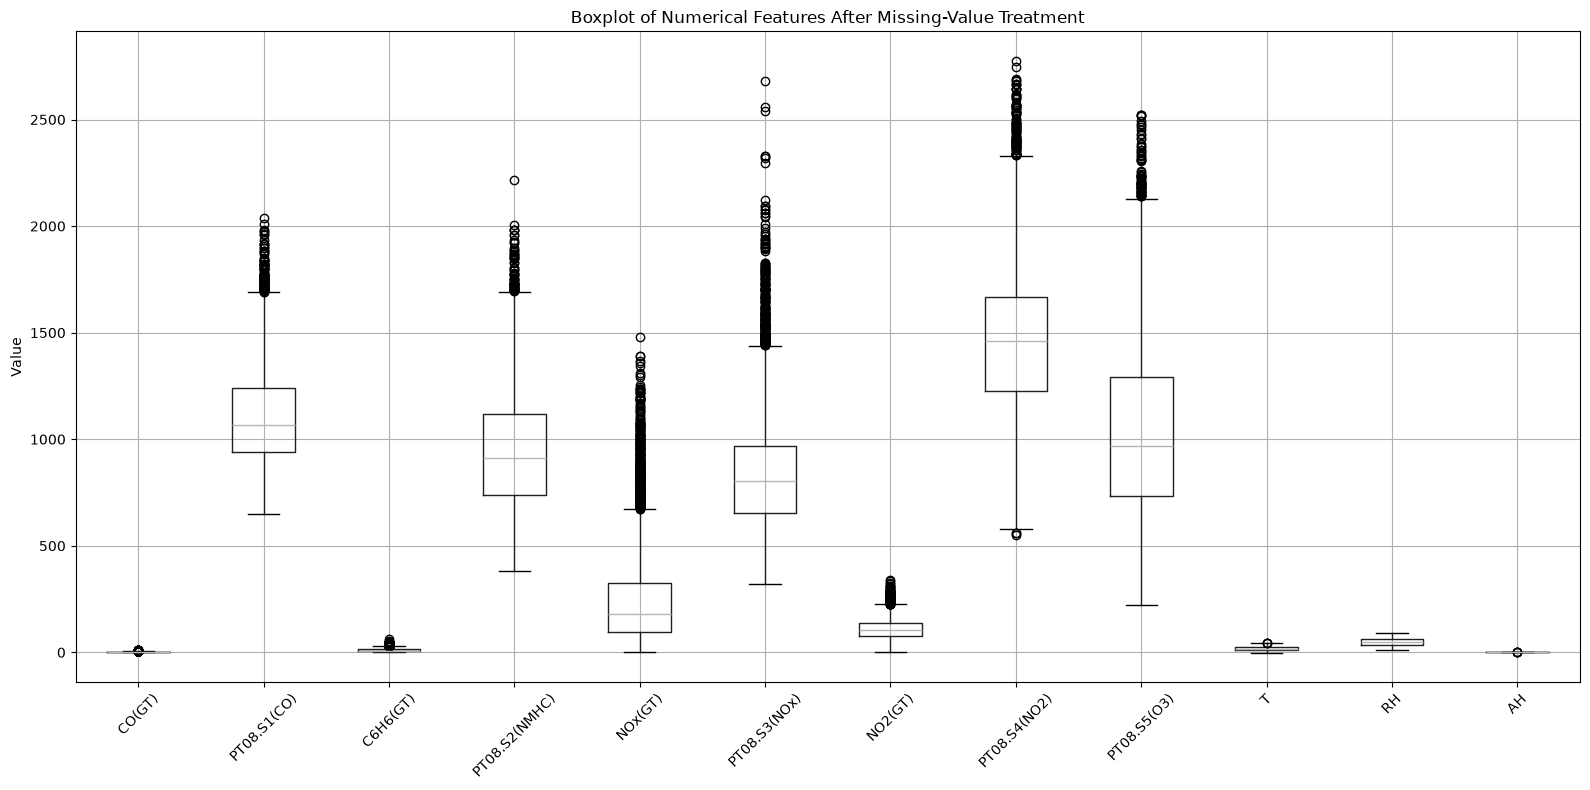

In [44]:
plt.figure(figsize=(16, 8))

df_clean[numeric_columns].boxplot()

plt.title("Boxplot of Numerical Features After Missing-Value Treatment")
plt.ylabel("Value")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [45]:
print("FINAL DATA QUALITY CHECK")
print("========================")

print("Rows:", df_clean.shape[0])
print("Columns:", df_clean.shape[1])
print("Missing values:", df_clean.isna().sum().sum())
print("Invalid -200 values:", (df_clean == -200).sum().sum())
print("Duplicate rows:", df_clean.duplicated().sum())
print("Data types:")
print(df_clean.dtypes)

FINAL DATA QUALITY CHECK
Rows: 9357
Columns: 15
Missing values: 0
Invalid -200 values: 0
Duplicate rows: 0
Data types:
Datetime         datetime64[us]
Date                        str
Time                        str
CO(GT)                  float64
PT08.S1(CO)             float64
C6H6(GT)                float64
PT08.S2(NMHC)           float64
NOx(GT)                 float64
PT08.S3(NOx)            float64
NO2(GT)                 float64
PT08.S4(NO2)            float64
PT08.S5(O3)             float64
T                       float64
RH                      float64
AH                      float64
dtype: object


## 10. Exploratory Data Analysis

After completing the data cleaning and preprocessing steps, Exploratory Data Analysis (EDA) was performed to understand the distributions, relationships, and temporal patterns present in the cleaned dataset.

The analysis focuses on the air-quality sensor measurements and meteorological variables such as temperature, relative humidity, and absolute humidity. Visualizations are used to identify patterns, relationships, and unusual observations that may be relevant for subsequent analysis.

In [46]:
print("Cleaned dataset shape:", df_clean.shape)
display(df_clean.head())

Cleaned dataset shape: (9357, 15)


,Datetime,Date,Time,CO(GT),PT08.S1(CO),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,2004-03-10 18:00:00,3/10/2004,18:00:00,2.6,1360.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,0.7578
1,2004-03-10 19:00:00,3/10/2004,19:00:00,2.0,1292.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,0.7255
2,2004-03-10 20:00:00,3/10/2004,20:00:00,2.2,1402.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,54.0,0.7502
3,2004-03-10 21:00:00,3/10/2004,21:00:00,2.2,1376.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203.0,11.0,60.0,0.7867
4,2004-03-10 22:00:00,3/10/2004,22:00:00,1.6,1272.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110.0,11.2,59.6,0.7888


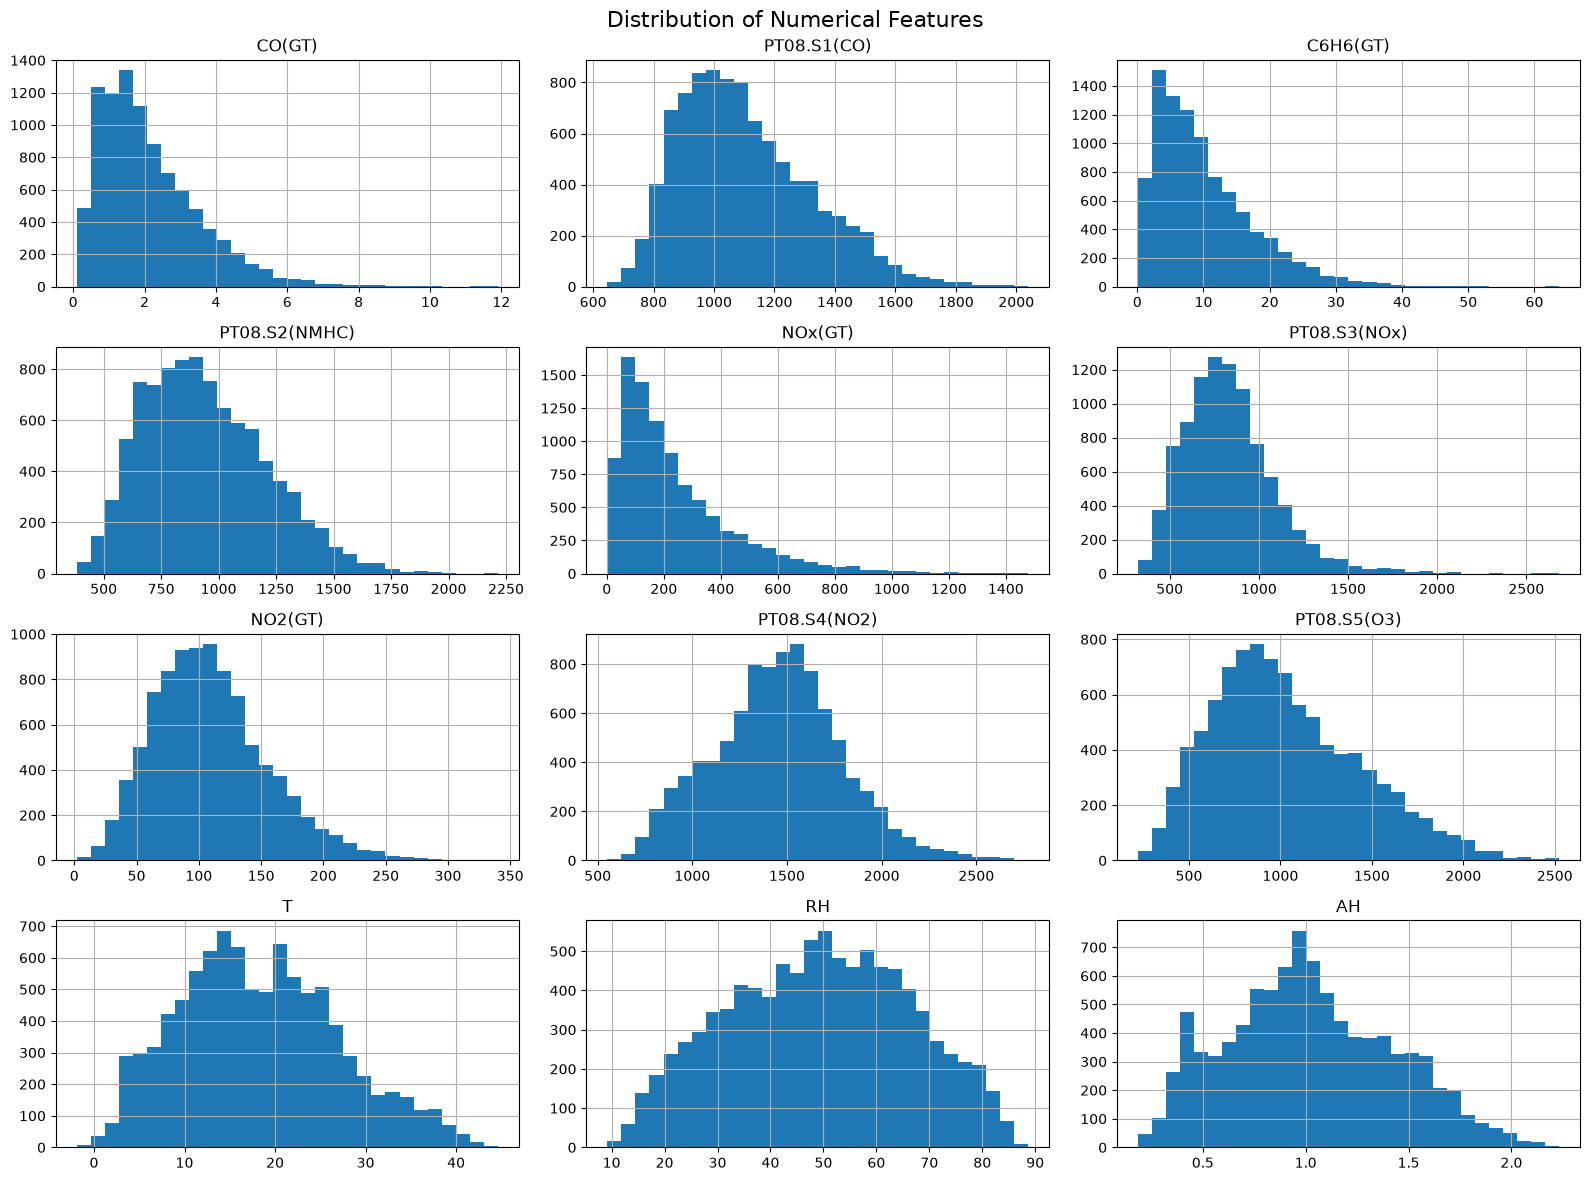

In [47]:
df_clean[numeric_columns].hist(
    figsize=(16, 12),
    bins=30
)

plt.suptitle("Distribution of Numerical Features", fontsize=16)
plt.tight_layout()
plt.show()

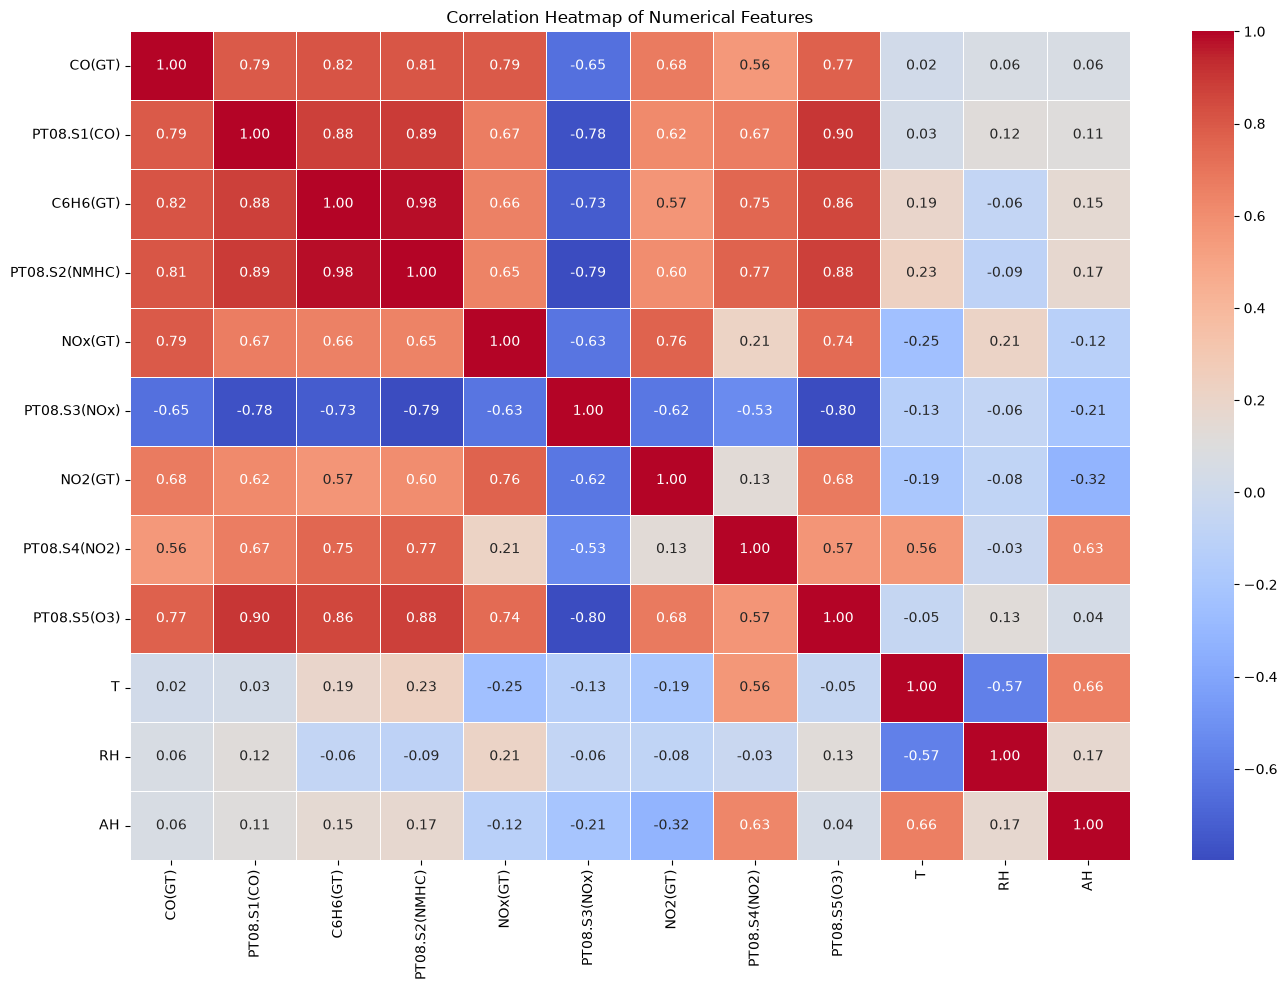

In [48]:
plt.figure(figsize=(14, 10))

correlation_matrix = df_clean[numeric_columns].corr()

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap of Numerical Features")
plt.tight_layout()
plt.show()

## 11. Time-Series Analysis

The dataset contains hourly air-quality measurements. Time-series analysis was performed to examine how pollution levels changed over the observation period.

The carbon monoxide (`CO(GT)`) concentration is used as an example indicator to visualize the temporal pattern of air pollution.

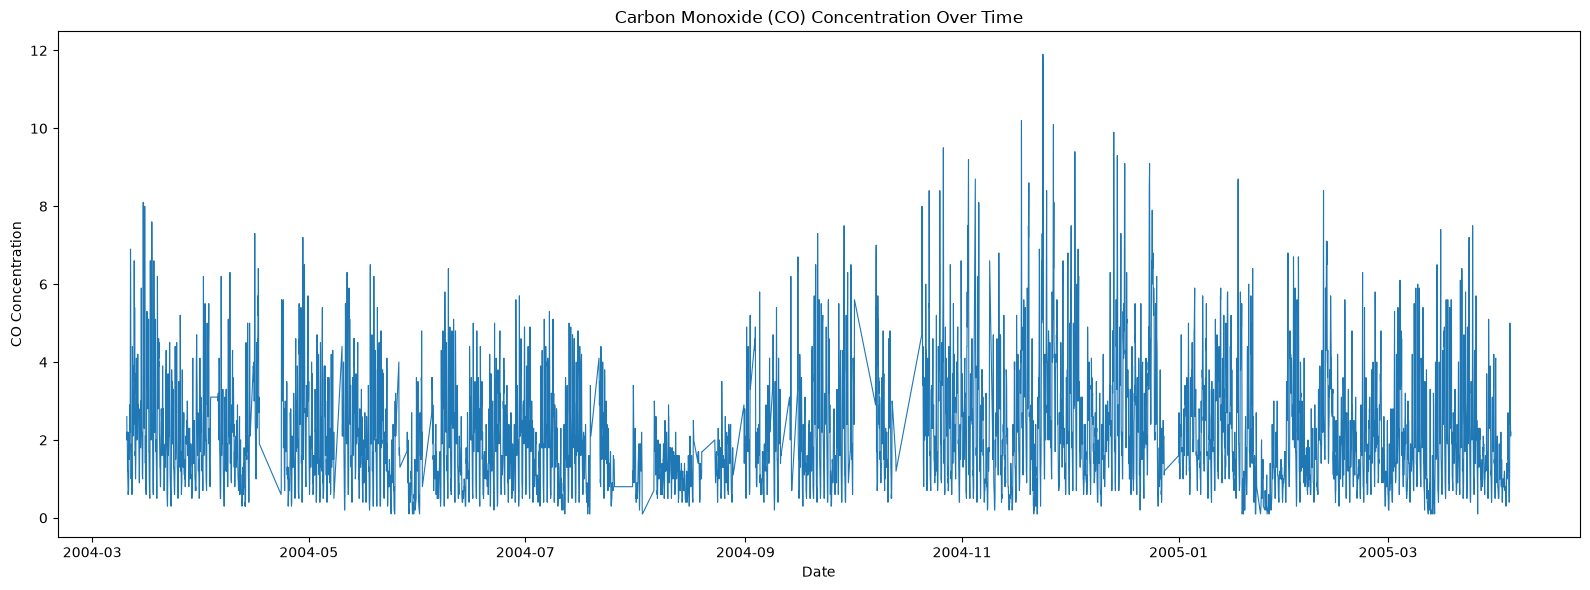

In [50]:
plt.figure(figsize=(16, 6))

plt.plot(
    df_clean["Datetime"],
    df_clean["CO(GT)"],
    linewidth=0.8
)

plt.title("Carbon Monoxide (CO) Concentration Over Time")
plt.xlabel("Date")
plt.ylabel("CO Concentration")
plt.tight_layout()
plt.show()

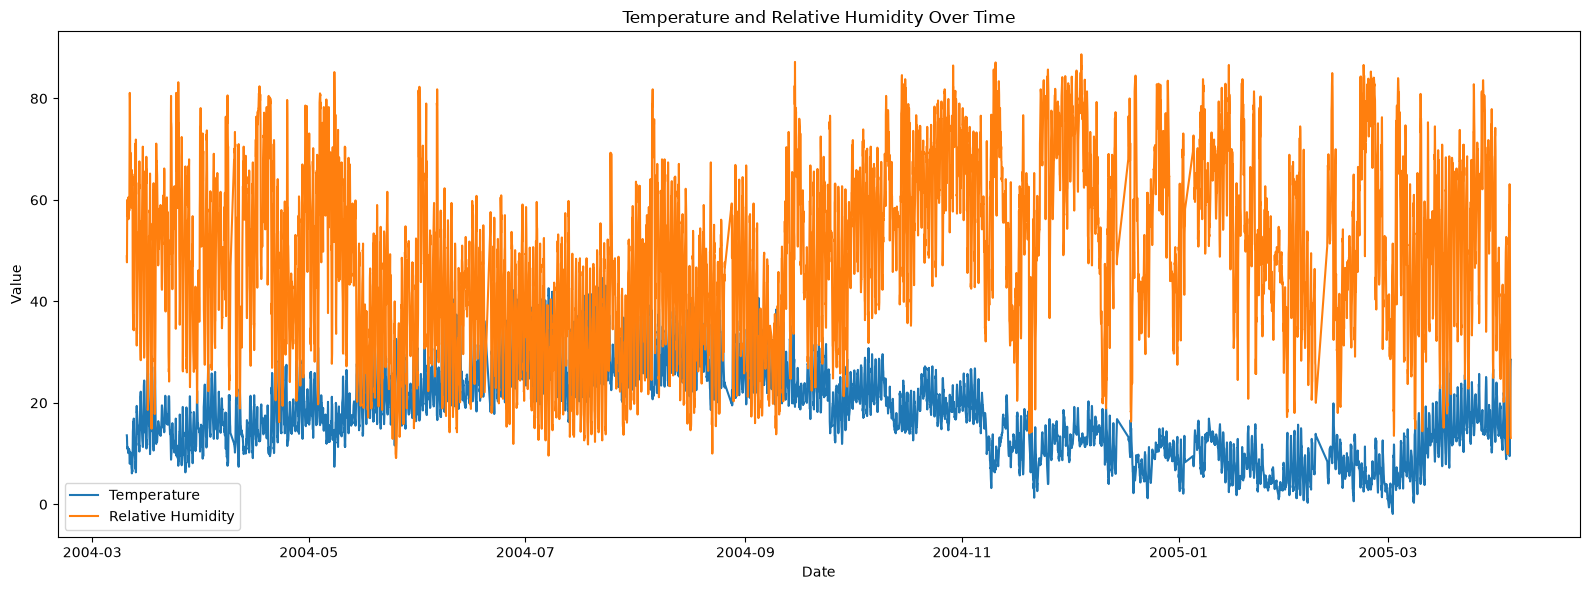

In [51]:
plt.figure(figsize=(16, 6))

plt.plot(
    df_clean["Datetime"],
    df_clean["T"],
    label="Temperature"
)

plt.plot(
    df_clean["Datetime"],
    df_clean["RH"],
    label="Relative Humidity"
)

plt.title("Temperature and Relative Humidity Over Time")
plt.xlabel("Date")
plt.ylabel("Value")
plt.legend()
plt.tight_layout()
plt.show()

In [52]:
df_clean[numeric_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
CO(GT),9357.0,2.130603,1.431736,0.1000,1.1000,1.800000,2.900000,11.900
PT08.S1(CO),9357.0,1103.059741,218.196346,647.0000,938.0000,1067.000000,1239.000000,2040.000
C6H6(GT),9357.0,10.179155,7.503812,0.1000,4.5000,8.300000,14.100000,63.700
PT08.S2(NMHC),9357.0,942.142620,267.866611,383.0000,736.0000,910.012987,1119.000000,2214.000
NOx(GT),9357.0,241.922197,204.315075,2.0000,96.0000,180.000000,326.000000,1479.000
PT08.S3(NOx),9357.0,832.758897,255.709833,322.0000,654.0000,804.000000,968.000000,2683.000
NO2(GT),9357.0,109.632094,46.462311,2.0000,76.0000,104.917526,136.314685,340.000
PT08.S4(NO2),9357.0,1453.298814,343.206131,551.0000,1227.0000,1460.000000,1668.000000,2775.000
PT08.S5(O3),9357.0,1032.544298,404.447613,221.0000,733.0000,970.000000,1293.000000,2523.000
T,9357.0,18.233408,8.781791,-1.9000,11.7000,17.600000,24.300000,44.600


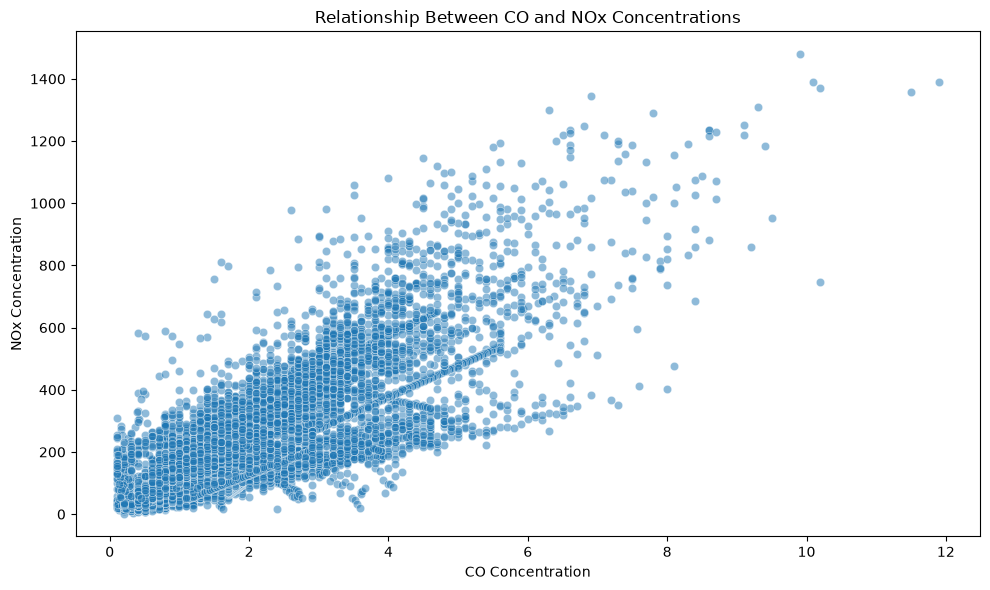

In [53]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df_clean,
    x="CO(GT)",
    y="NOx(GT)",
    alpha=0.5
)

plt.title("Relationship Between CO and NOx Concentrations")
plt.xlabel("CO Concentration")
plt.ylabel("NOx Concentration")
plt.tight_layout()
plt.show()

In [54]:
print(df_clean.shape)
print(df_clean.columns.tolist())

(9357, 15)
['Datetime', 'Date', 'Time', 'CO(GT)', 'PT08.S1(CO)', 'C6H6(GT)', 'PT08.S2(NMHC)', 'NOx(GT)', 'PT08.S3(NOx)', 'NO2(GT)', 'PT08.S4(NO2)', 'PT08.S5(O3)', 'T', 'RH', 'AH']


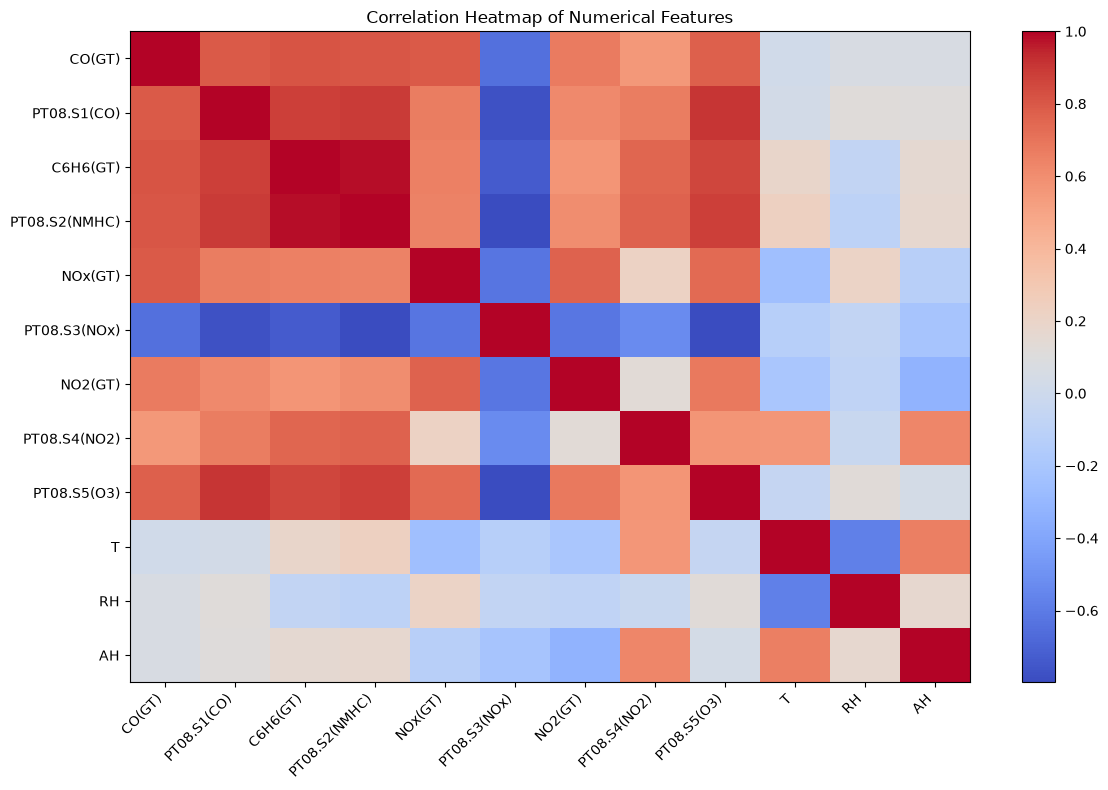

In [55]:
import matplotlib.pyplot as plt
import pandas as pd

corr = df_clean[numeric_columns].corr()

plt.figure(figsize=(12, 8))
plt.imshow(corr, cmap="coolwarm", aspect="auto")
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha="right")
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation Heatmap of Numerical Features")
plt.tight_layout()
plt.show()

In [56]:
# Save the final cleaned dataset

output_file = "AirQuality_cleaned.csv"

df_clean.to_csv(output_file, index=False)

print("Cleaned dataset saved successfully!")
print("File:", output_file)
print("Shape:", df_clean.shape)

Cleaned dataset saved successfully!
File: AirQuality_cleaned.csv
Shape: (9357, 15)


In [57]:
# Verify the exported CSV

df_check = pd.read_csv("AirQuality_cleaned.csv")

print("Rows:", df_check.shape[0])
print("Columns:", df_check.shape[1])
print("Missing values:", df_check.isna().sum().sum())
print("Duplicate rows:", df_check.duplicated().sum())

Rows: 9357
Columns: 15
Missing values: 0
Duplicate rows: 0
